# 03 — Causal Inference: Voucher Evaluation
Difference-in-Differences (DiD) — measuring true causal effect of incentives

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

In [2]:
df = pd.read_csv('sample_rides.csv', parse_dates=['timestamp'])
print(f"Pre-period:  {(df['post_period']==0).sum()} rides")
print(f"Post-period: {(df['post_period']==1).sum()} rides")
print(f"Voucher rate pre:  {df[df['post_period']==0]['voucher_applied'].mean():.1%}")
print(f"Voucher rate post: {df[df['post_period']==1]['voucher_applied'].mean():.1%}")

Pre-period:  477 rides
Post-period: 523 rides
Voucher rate pre:  4.2%
Voucher rate post: 29.4%


## Parallel trends check

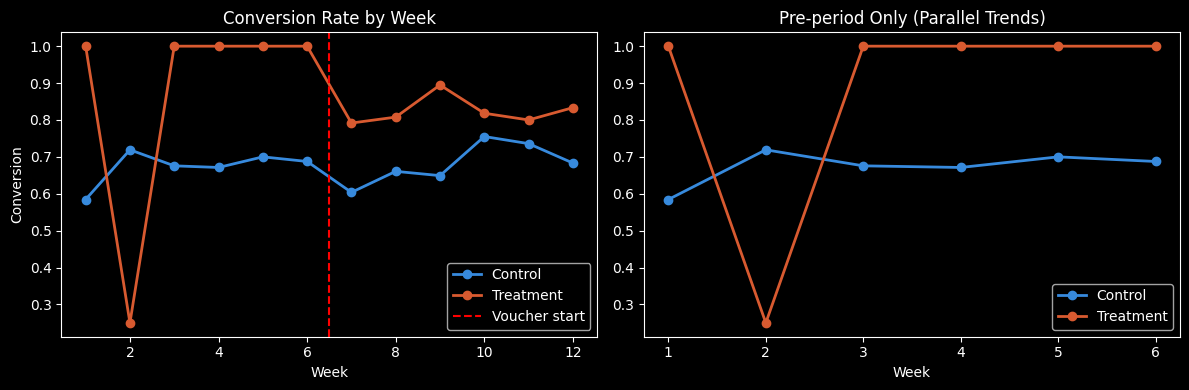

Interaction coef (pre-period): 0.05259
Parallel trends: CHECK


In [3]:
weekly = df.groupby(['week','voucher_applied'])['conversion'].mean().reset_index()
weekly.columns = ['week','voucher','conv']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for v, label, color in [(0,'Control','#378ADD'),(1,'Treatment','#D85A30')]:
    g = weekly[weekly['voucher']==v]
    axes[0].plot(g['week'], g['conv'], marker='o', lw=2, label=label, color=color)
axes[0].axvline(6.5, color='red', ls='--', lw=1.5, label='Voucher start')
axes[0].set(title='Conversion Rate by Week', xlabel='Week', ylabel='Conversion')
axes[0].legend()

pre_w = weekly[weekly['week'] <= 6]
for v, label, color in [(0,'Control','#378ADD'),(1,'Treatment','#D85A30')]:
    g = pre_w[pre_w['voucher']==v]
    axes[1].plot(g['week'], g['conv'], marker='o', lw=2, label=label, color=color)
axes[1].set(title='Pre-period Only (Parallel Trends)', xlabel='Week')
axes[1].legend()
plt.tight_layout()
plt.show()

pre_df = df[df['post_period']==0]
X = np.column_stack([np.ones(len(pre_df)), pre_df['voucher_applied'],
                     pre_df['week'], pre_df['voucher_applied']*pre_df['week']])
coef, _, _, _ = lstsq(X, pre_df['conversion'].values, rcond=None)
print(f'Interaction coef (pre-period): {coef[3]:.5f}')
print('Parallel trends:', 'SATISFIED' if abs(coef[3]) < 0.01 else 'CHECK')

## DiD estimation

In [4]:
t_pre  = df[(df['voucher_applied']==1)&(df['post_period']==0)]['conversion'].mean()
c_pre  = df[(df['voucher_applied']==0)&(df['post_period']==0)]['conversion'].mean()
t_post = df[(df['voucher_applied']==1)&(df['post_period']==1)]['conversion'].mean()
c_post = df[(df['voucher_applied']==0)&(df['post_period']==1)]['conversion'].mean()

did = (t_post - t_pre) - (c_post - c_pre)

print(f"{'':22} {'Pre':>8} {'Post':>8} {'Delta':>8}")
print(f"{'Treatment':22} {t_pre:>8.4f} {t_post:>8.4f} {t_post-t_pre:>+8.4f}")
print(f"{'Control':22} {c_pre:>8.4f} {c_post:>8.4f} {c_post-c_pre:>+8.4f}")
print(f"{'DiD estimate':22} {'':>8} {'':>8} {did:>+8.4f}")
print(f'\nDiD = {did:.4f}  ({did*100:+.2f} pp)')

                            Pre     Post    Delta
Treatment                0.8500   0.8247  -0.0253
Control                  0.6740   0.6802  +0.0063
DiD estimate                              -0.0316

DiD = -0.0316  (-3.16 pp)


## Bootstrap CI

In [5]:
np.random.seed(42)
boot = []
for _ in range(2000):
    s = df.sample(len(df), replace=True)
    b = ((s[(s['voucher_applied']==1)&(s['post_period']==1)]['conversion'].mean() -
          s[(s['voucher_applied']==1)&(s['post_period']==0)]['conversion'].mean()) -
         (s[(s['voucher_applied']==0)&(s['post_period']==1)]['conversion'].mean() -
          s[(s['voucher_applied']==0)&(s['post_period']==0)]['conversion'].mean()))
    boot.append(b)

ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
se = np.std(boot)
p  = 2*(1 - stats.norm.cdf(abs(did/se)))
print(f'DiD estimate : {did:+.4f}')
print(f'95% CI       : [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'p-value      : {p:.4f} -> {"SIGNIFICANT" if p<0.05 else "not significant"}')

DiD estimate : -0.0316
95% CI       : [-0.2055, 0.1677]
p-value      : 0.7372 -> not significant


## Visualise

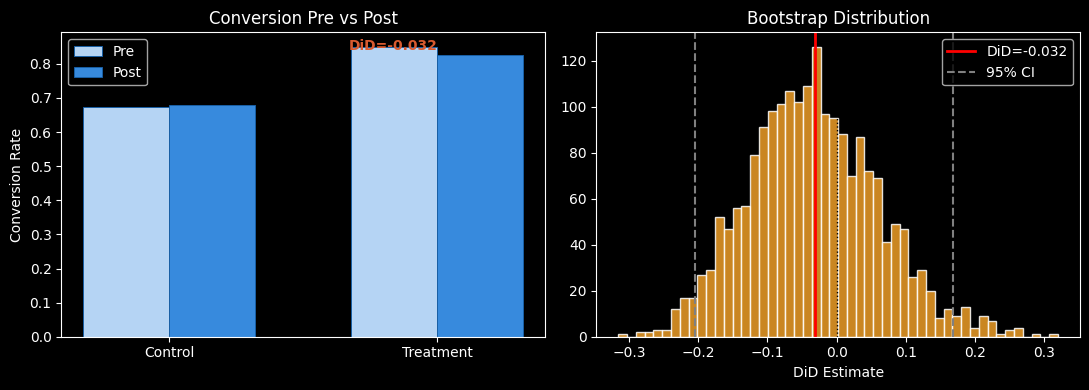

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(2); w = 0.32
axes[0].bar(x-w/2, [c_pre,t_pre],   w, label='Pre',  color='#B5D4F4', edgecolor='#185FA5', lw=0.7)
axes[0].bar(x+w/2, [c_post,t_post], w, label='Post', color='#378ADD', edgecolor='#185FA5', lw=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Control','Treatment'])
axes[0].set(title='Conversion Pre vs Post', ylabel='Conversion Rate')
axes[0].legend()
axes[0].annotate(f'DiD={did:+.3f}', xy=(1, max(t_post,c_post)*1.02),
                 ha='right', color='#D85A30', fontweight='bold')
axes[1].hist(boot, bins=50, color='#EF9F27', alpha=0.85, edgecolor='white')
axes[1].axvline(did,   color='red',  lw=2,   label=f'DiD={did:.3f}')
axes[1].axvline(ci_lo, color='gray', lw=1.5, ls='--', label='95% CI')
axes[1].axvline(ci_hi, color='gray', lw=1.5, ls='--')
axes[1].axvline(0,     color='black',lw=1,   ls=':')
axes[1].set(title='Bootstrap Distribution', xlabel='DiD Estimate')
axes[1].legend()
plt.tight_layout()
plt.show()

## Voucher ROI

In [7]:
avg_disc = df[df['voucher_applied']==1]['voucher_discount_eur'].mean()
avg_val  = df[df['conversion']==1]['final_price_eur'].mean()
incr     = did * 100
cost     = avg_disc * 100
revenue  = incr * avg_val
print(f'Avg discount       : EUR {avg_disc:.2f}')
print(f'Avg ride value     : EUR {avg_val:.2f}')
print(f'Incremental /100   : {incr:.1f} rides')
print(f'Cost /100 vouchers : EUR {cost:.2f}')
print(f'Revenue /100       : EUR {revenue:.2f}')
print(f'Net margin /100    : EUR {revenue-cost:.2f}')
print(f'ROI                : {(revenue/cost-1)*100:.0f}%')

Avg discount       : EUR 2.52
Avg ride value     : EUR 7.92
Incremental /100   : -3.2 rides
Cost /100 vouchers : EUR 251.52
Revenue /100       : EUR -25.01
Net margin /100    : EUR -276.53
ROI                : -110%
